# Adversarial Reprogramming of Growing Neural Cellular Automata

This notebook contains code to reproduce experiments and figures regarding Growing CAs for the "Adversarial Reprogramming of Neural Cellular Automata" article.

Copyright 2020 Google LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    https://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.

# Common code for both experiments

In [1]:
# Colab GPU check

import torch
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")

Tesla T4


In [2]:
# Use legacy keras - because code uses keras v2 and not v3

import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

In [ ]:
#@title Imports and Notebook Utilities
%tensorflow_version 2.x

import os
import io
import PIL.Image, PIL.ImageDraw
import base64
import zipfile
import json
import requests
import numpy as np
import matplotlib.pylab as pl
import glob

import tensorflow as tf
# from tensorflow.keras import mixed_precision
# mixed_precision.set_global_policy('mixed_float16')

from IPython.display import Image, HTML, clear_output
import tqdm

import os
os.environ['FFMPEG_BINARY'] = 'ffmpeg'
import moviepy.editor as mvp
from moviepy.video.io.ffmpeg_writer import FFMPEG_VideoWriter
clear_output()

%pip install cma
import cma

def np2pil(a):
  if a.dtype in [np.float32, np.float64]:
    a = np.uint8(np.clip(a, 0, 1)*255)
  return PIL.Image.fromarray(a)

def imwrite(f, a, fmt=None):
  a = np.asarray(a)
  if isinstance(f, str):
    fmt = f.rsplit('.', 1)[-1].lower()
    if fmt == 'jpg':
      fmt = 'jpeg'
    f = open(f, 'wb')
  np2pil(a).save(f, fmt, quality=95)

def imencode(a, fmt='jpeg'):
  a = np.asarray(a)
  if len(a.shape) == 3 and a.shape[-1] == 4:
    fmt = 'png'
  f = io.BytesIO()
  imwrite(f, a, fmt)
  return f.getvalue()

def im2url(a, fmt='jpeg'):
  encoded = imencode(a, fmt)
  base64_byte_string = base64.b64encode(encoded).decode('ascii')
  return 'data:image/' + fmt.upper() + ';base64,' + base64_byte_string

def imshow(a, fmt='jpeg'):
  display(Image(data=imencode(a, fmt)))

def tile2d(a, w=None):
  a = np.asarray(a)
  if w is None:
    w = int(np.ceil(np.sqrt(len(a))))
  th, tw = a.shape[1:3]
  pad = (w-len(a))%w
  a = np.pad(a, [(0, pad)]+[(0, 0)]*(a.ndim-1), 'constant')
  h = len(a)//w
  a = a.reshape([h, w]+list(a.shape[1:]))
  a = np.rollaxis(a, 2, 1).reshape([th*h, tw*w]+list(a.shape[4:]))
  return a

def zoom(img, scale=4):
  img = np.repeat(img, scale, 0)
  img = np.repeat(img, scale, 1)
  return img

class VideoWriter:
  def __init__(self, filename, fps=30.0, **kw):
    self.writer = None
    self.params = dict(filename=filename, fps=fps, **kw)

  def add(self, img):
    img = np.asarray(img)
    if self.writer is None:
      h, w = img.shape[:2]
      self.writer = FFMPEG_VideoWriter(size=(w, h), **self.params)
    if img.dtype in [np.float32, np.float64]:
      img = np.uint8(img.clip(0, 1)*255)
    if len(img.shape) == 2:
      img = np.repeat(img[..., None], 3, -1)
    self.writer.write_frame(img)

  def close(self):
    if self.writer:
      self.writer.close()

  def __enter__(self):
    return self

  def __exit__(self, *kw):
    self.close()

In [ ]:
#@title Cellular Automata Parameters
CHANNEL_N = 16        # Number of CA state channels
TARGET_SIZE = 40
BATCH_SIZE = 8
POOL_SIZE = 1024
CELL_FIRE_RATE = 0.5

EXPERIMENT_TYPE = "Regenerating" #@param ["Persistent", "Regenerating"]
EXPERIMENT_MAP = {"Persistent":0, "Regenerating":1}
EXPERIMENT_N = EXPERIMENT_MAP[EXPERIMENT_TYPE]

DAMAGE_N = [0, 3][EXPERIMENT_N]  # Number of patterns to damage in a batch

In [5]:
#@title CA Model and Utilities
#@markdown This model doesn't have a bias in the last layer.
from tensorflow.keras.layers import Conv2D

def load_image(url, max_size=TARGET_SIZE):
  r = requests.get(url)
  img = PIL.Image.open(io.BytesIO(r.content))
  img.thumbnail((max_size, max_size), PIL.Image.LANCZOS)
  img = np.float32(img)/255.0
  # premultiply RGB by Alpha
  img[..., :3] *= img[..., 3:]
  return img

def to_rgba(x):
  return x[..., :4]

def to_alpha(x):
  return tf.clip_by_value(x[..., 3:4], 0.0, 1.0)

def to_rgb(x):
  # assume rgb premultiplied by alpha
  rgb, a = x[..., :3], to_alpha(x)
  return 1.0-a+rgb

def get_living_mask(x):
  alpha = x[:, :, :, 3:4]
  return tf.nn.max_pool2d(alpha, 3, [1, 1, 1, 1], 'SAME') > 0.1

def make_seed(size, n=1):
  x = np.zeros([n, size, size, CHANNEL_N], np.float32)
  x[:, size//2, size//2, 3:] = 1.0
  return x


class CAModel(tf.keras.Model):

  def __init__(self, channel_n=CHANNEL_N, fire_rate=CELL_FIRE_RATE):
    super().__init__()
    self.channel_n = channel_n
    self.fire_rate = fire_rate

    self.dmodel = tf.keras.Sequential([
          Conv2D(128, 1, activation=tf.nn.relu),
          Conv2D(self.channel_n, 1, activation=None,
              kernel_initializer=tf.zeros_initializer),
    ])

    self(tf.zeros([1, 3, 3, channel_n]))  # dummy call to build the model

  @tf.function
  def perceive(self, x, angle=0.0):
    identify = np.float32([0, 1, 0])
    identify = np.outer(identify, identify)
    dx = np.outer([1, 2, 1], [-1, 0, 1]) / 8.0  # Sobel filter
    dy = dx.T
    c, s = tf.cos(angle), tf.sin(angle)
    kernel = tf.stack([identify, c*dx-s*dy, s*dx+c*dy], -1)[:, :, None, :]
    kernel = tf.repeat(kernel, self.channel_n, 2)
    y = tf.nn.depthwise_conv2d(x, kernel, [1, 1, 1, 1], 'SAME')
    return y

  @tf.function
  def call(self, x, fire_rate=None, angle=0.0, step_size=1.0):
    pre_life_mask = get_living_mask(x)

    y = self.perceive(x, angle)
    dx = self.dmodel(y)*step_size
    if fire_rate is None:
      fire_rate = self.fire_rate
    update_mask = tf.random.uniform(tf.shape(x[:, :, :, :1])) <= fire_rate
    x += dx * tf.cast(update_mask, tf.float32)

    post_life_mask = get_living_mask(x)
    life_mask = pre_life_mask & post_life_mask
    return x * tf.cast(life_mask, tf.float32)


CAModel().dmodel.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (1, 3, 3, 128)            6272      
                                                                 
 conv2d_1 (Conv2D)           (1, 3, 3, 16)             2064      
                                                                 
Total params: 8336 (32.56 KB)
Trainable params: 8336 (32.56 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [6]:
#@title Train Utilities (SamplePool, Model Export, Damage)
from google.protobuf.json_format import MessageToDict
from tensorflow.python.framework import convert_to_constants

class SamplePool:
  def __init__(self, *, _parent=None, _parent_idx=None, **slots):
    self._parent = _parent
    self._parent_idx = _parent_idx
    self._slot_names = slots.keys()
    self._size = None
    for k, v in slots.items():
      if self._size is None:
        self._size = len(v)
      assert self._size == len(v)
      setattr(self, k, np.asarray(v))

  def sample(self, n):
    idx = np.random.choice(self._size, n, False)
    batch = {k: getattr(self, k)[idx] for k in self._slot_names}
    batch = SamplePool(**batch, _parent=self, _parent_idx=idx)
    return batch

  def commit(self):
    for k in self._slot_names:
      getattr(self._parent, k)[self._parent_idx] = getattr(self, k)

@tf.function
def make_circle_masks(n, h, w):
  x = tf.linspace(-1.0, 1.0, w)[None, None, :]
  y = tf.linspace(-1.0, 1.0, h)[None, :, None]
  center = tf.random.uniform([2, n, 1, 1], -0.5, 0.5)
  r = tf.random.uniform([n, 1, 1], 0.1, 0.4)
  x, y = (x-center[0])/r, (y-center[1])/r
  mask = tf.cast(x*x+y*y < 1.0, tf.float32)
  return mask

def export_model(ca, base_fn):
  ca.save_weights(base_fn)

  cf = ca.call.get_concrete_function(
      x=tf.TensorSpec([None, None, None, CHANNEL_N]),
      fire_rate=tf.constant(0.5),
      angle=tf.constant(0.0),
      step_size=tf.constant(1.0))
  cf = convert_to_constants.convert_variables_to_constants_v2(cf)
  graph_def = cf.graph.as_graph_def()
  graph_json = MessageToDict(graph_def)
  graph_json['versions'] = dict(producer='1.14', minConsumer='1.14')
  model_json = {
      'format': 'graph-model',
      'modelTopology': graph_json,
      'weightsManifest': [],
  }
  with open(base_fn+'.json', 'w') as f:
    json.dump(model_json, f)

def generate_pool_figures(pool, step_i):
  tiled_pool = tile2d(to_rgb(pool.x[:49]))
  fade = np.linspace(1.0, 0.0, 72)
  ones = np.ones(72)
  tiled_pool[:, :72] += (-tiled_pool[:, :72] + ones[None, :, None]) * fade[None, :, None]
  tiled_pool[:, -72:] += (-tiled_pool[:, -72:] + ones[None, :, None]) * fade[None, ::-1, None]
  tiled_pool[:72, :] += (-tiled_pool[:72, :] + ones[:, None, None]) * fade[:, None, None]
  tiled_pool[-72:, :] += (-tiled_pool[-72:, :] + ones[:, None, None]) * fade[::-1, None, None]
  imwrite('train_log/%04d_pool.jpg'%step_i, tiled_pool)

def visualize_batch(x0, x, step_i):
  vis0 = np.hstack(to_rgb(x0).numpy())
  vis1 = np.hstack(to_rgb(x).numpy())
  vis = np.vstack([vis0, vis1])
  imwrite('train_log/batches_%04d.jpg'%step_i, vis)
  print('batch (before/after):')
  imshow(vis)

def plot_loss(loss_log):
  pl.figure(figsize=(10, 4))
  pl.title('Loss history (log10)')
  pl.plot(np.log10(loss_log), '.', alpha=0.1)
  pl.show()


In [7]:
!wget -O models.zip 'https://github.com/google-research/self-organising-systems/blob/master/assets/growing_ca/models.zip?raw=true'
!unzip -oq models.zip

# available pretrained emoji are:
#EMOJI = '🦎😀💥👁🐠🦋🐞🕸🥨🎄'

def get_model(emoji='🦎', fire_rate=0.5, use_pool=1, damage_n=3, run=0,
              prefix='models/', output='model'):
  path = prefix
  assert fire_rate in [0.5, 1.0]
  if fire_rate==0.5:
    path += 'use_sample_pool_%d damage_n_%d '%(use_pool, damage_n)
  elif fire_rate==1.0:
    path += 'fire_rate_1.0 '
  code = hex(ord(emoji))[2:].upper()
  path += 'target_emoji_%s run_index_%d/08000'%(code, run)
  assert output in ['model', 'json']
  if output == 'model':
    ca = CAModel(channel_n=16, fire_rate=fire_rate)
    ca.load_weights(path)
    return ca
  elif output == 'json':
    return open(path+'.json', 'r').read()

def get_local_model(path, output='model'):
  assert output in ['model', 'json']
  if output == 'model':
    ca = CAModel(channel_n=16)
    ca.load_weights(path)
    return ca
  elif output == 'json':
    return open(path+'.json', 'r').read()


--2026-05-17 10:43:53--  https://github.com/google-research/self-organising-systems/blob/master/assets/growing_ca/models.zip?raw=true
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/google-research/self-organising-systems/raw/refs/heads/master/assets/growing_ca/models.zip [following]
--2026-05-17 10:43:53--  https://github.com/google-research/self-organising-systems/raw/refs/heads/master/assets/growing_ca/models.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/google-research/self-organising-systems/refs/heads/master/assets/growing_ca/models.zip [following]
--2026-05-17 10:43:54--  https://raw.githubusercontent.com/google-research/self-organising-systems/refs/heads/master/assets/growing_ca/models.zip
Resolving raw.githubusercontent.com (raw.gi

## CA Targets

In [8]:
!wget -O growing_ca_target_images.zip 'https://github.com/google-research/self-organising-systems/blob/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip?raw=true'
!unzip -oq "growing_ca_target_images.zip" -d "target_pics"
!ls target_pics/

--2026-05-17 10:43:55--  https://github.com/google-research/self-organising-systems/blob/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip?raw=true
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/google-research/self-organising-systems/raw/refs/heads/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip [following]
--2026-05-17 10:43:55--  https://github.com/google-research/self-organising-systems/raw/refs/heads/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/google-research/self-organising-systems/refs/heads/master/adversarial_reprogramming_ca/assets/growing_ca_target_images.zip [following]
--2026-05-17 10:43:55--  https://raw.githubus

In [10]:
# If you want a new picture, modify it with either:
# - https://pixlr.com/
# - https://www.piskelapp.com/
def load_image_from_file(fp, max_size=TARGET_SIZE):
  img = PIL.Image.open(fp)
  img.thumbnail((max_size, max_size), PIL.Image.LANCZOS)
  img = np.float32(img)/255.0
  # premultiply RGB by Alpha
  img[..., :3] *= img[..., 3:]
  return img

pic_prefix = "target_pics/"
lizard_no_tail_fp = pic_prefix + "lizard_no_tail.png"
lizard_no_leg_fp = pic_prefix + "lizard_no_leg.png"
lizard_no_head_fp = pic_prefix + "lizard_no_head.png"
lizard_no_arm_fp = pic_prefix + "lizard_no_arm.png"
lizard_red_fp = pic_prefix + "lizard_red.png"
lizard_blue_fp = pic_prefix + "lizard_blue.png"
butterfly_left_orange_fp = pic_prefix + "butterfly_left_orange.png"
butterfly_all_orange_fp = pic_prefix + "butterfly_all_orange.png"
butterfly_original_fp = pic_prefix + "butterfly_original.png"

lizard_complete_fp = pic_prefix + "lizard_complete.png"

target_map = {
    "liz_no_tail": lizard_no_tail_fp,
    "lizard_no_leg": lizard_no_leg_fp,
    "lizard_no_head": lizard_no_head_fp,
    "lizard_no_arm": lizard_no_arm_fp,
    "lizard_red": lizard_red_fp,
    "lizard_blue": lizard_blue_fp,
    "butterfly_left_orange": butterfly_left_orange_fp,
    "butterfly_original": butterfly_original_fp,
    }

# Experiment: State perturbations

We get a pretrained model (lizard) and train a state mutation to make it grow with missing limbs or different colors.

The mutation is applied at all states.

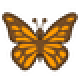

In [11]:
target_label = 'butterfly_original' #@param ["liz_no_tail", "liz_no_leg", "liz_no_head", "lizard_no_arm", "lizard_red", "lizard_blue"]

target_img = load_image_from_file(target_map[target_label])
imshow(zoom(to_rgb(target_img), 2), fmt='png')

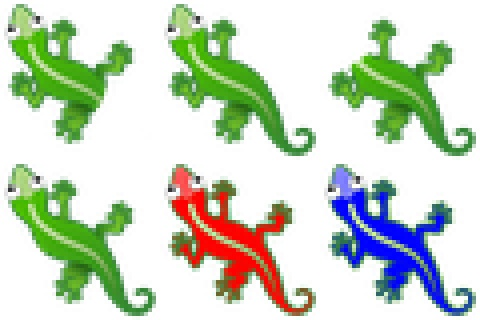

In [12]:
# compose picture of all perturbations
perts_fp_list = [lizard_no_tail_fp, lizard_no_leg_fp, lizard_no_head_fp, lizard_no_arm_fp, lizard_red_fp, lizard_blue_fp]
perts_img_list = [to_rgb(load_image_from_file(pfp)) for pfp in perts_fp_list]

imshow(zoom(tile2d(perts_img_list), 4))

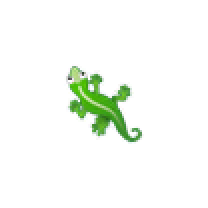

In [13]:
#@title Initialize Training { vertical-output: true}
TARGET_PADDING = 32 # From the previous section

p = TARGET_PADDING
pad_target = tf.pad(target_img, [(p, p), (p, p), (0, 0)])
h, w = pad_target.shape[:2]
seed = np.zeros([h, w, CHANNEL_N], np.float32)
seed[h//2, w//2, 3:] = 1.0

def loss_f(x):
  return tf.reduce_mean(tf.square(to_rgba(x)-pad_target), [-2, -3, -1])

target_emoji = '🦎' # '🦋'
ca = get_model(emoji=target_emoji)

# Generate the final state to modify.
x0_seed = seed[None, ...]
for gen in tf.range(200):
  x0_seed = ca(x0_seed)
imshow(zoom(to_rgb(x0_seed[0]), 2), fmt='png')

loss_log = []


loss0 = loss_f(seed).numpy()

initial_pool_elems = np.concatenate([
    np.repeat(seed[None, ...], POOL_SIZE // 2, 0),
    np.repeat(x0_seed, POOL_SIZE // 2, 0)], 0)
pool = SamplePool(x=initial_pool_elems)


# New for CMA-ES

iu = np.triu_indices(16)         # row/col indices of upper triangle incl. diagonal; iu[0] and iu[1] are each length 136

init_vec = np.eye(16, dtype=np.float32)[iu]   # length 136, ones on positions where iu[0]==iu[1], zeros elsewhere. Starting vector for the ES

!mkdir -p train_log && rm -f train_log/*

Random attack matrix shape: (16, 16)
Lizard after 3 steps of random matrix attack:


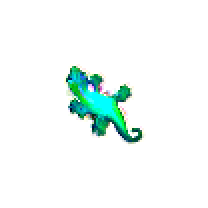

In [17]:
# ============================================================
# Random matrix attack: apply a random symmetric perturbation
# for a small number of steps and visualize the deformed lizard.
# ============================================================

# np.random.seed(42) 
random_mat = np.random.randn(CHANNEL_N, CHANNEL_N).astype(np.float32)
# Make it symmetric: M = (M + M.T) / 2
random_mat = (random_mat + random_mat.T) / 2

strength = 0.1
random_mat = tf.eye(CHANNEL_N) + strength * random_mat   # start from identity

# random_mat = random_mat   # pure random (no identity bias)

print("Random attack matrix shape:", random_mat.shape)

x_attack = seed[None, ...]   # shape (1, H, W, C)
for _ in range(200):         # Let it grow fully first (same as training snippet)
    x_attack = ca(x_attack)

attack_steps = 3
for step in range(attack_steps):
    lm = tf.cast(get_living_mask(x_attack), tf.float32)
    x_attack = x_attack @ random_mat
    x_attack = tf.clip_by_value(x_attack, -3.0, 3.0)
    x_attack = x_attack * lm
    x_attack = ca(x_attack)   

print(f"Lizard after {attack_steps} steps of random matrix attack:")
imshow(zoom(to_rgb(x_attack[0]), 2), fmt='png')

In [18]:
print(random_mat)

tf.Tensor(
[[ 8.70141029e-01 -8.06449389e-04 -3.00469110e-03 -1.39724061e-01
   7.22788274e-02 -3.56219932e-02 -6.60626516e-02 -2.72330618e-03
   7.04073254e-03  4.41627838e-02  2.03150809e-02 -1.98805192e-03
   5.39163947e-02  4.25766706e-02 -1.51461467e-01 -4.74609211e-02]
 [-8.06449389e-04  9.21334326e-01 -5.31757139e-02  2.11365391e-02
  -8.46034661e-02  1.03592433e-01  3.92330326e-02  7.81852230e-02
   4.69691716e-02  4.62042801e-02 -3.80850248e-02 -1.55363902e-01
   1.11346869e-02 -1.60825250e-04 -1.50036067e-06 -1.45826433e-02]
 [-3.00469110e-03 -5.31757139e-02  1.01913631e+00  6.43292591e-02
  -1.63788036e-01 -1.05832890e-01  1.54773686e-02  5.91644458e-02
  -8.77575800e-02 -1.29834255e-02  2.45836321e-02 -7.28925169e-02
  -4.32225456e-03 -1.21918581e-01  4.11681719e-02 -2.09030304e-02]
 [-1.39724061e-01  2.11365391e-02  6.43292591e-02  1.19126558e+00
  -1.44423014e-02  7.71686956e-02 -4.20894884e-02  5.61197512e-02
   4.16967459e-02 -7.61574879e-02 -5.17793000e-03  7.41336867e

batch (before/after):


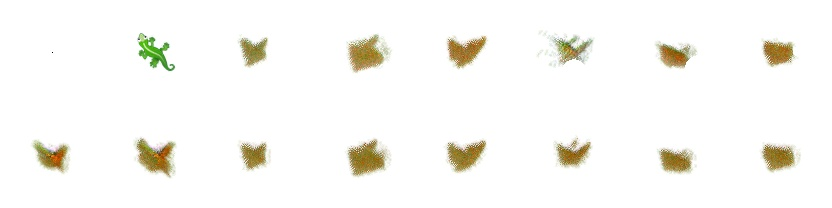

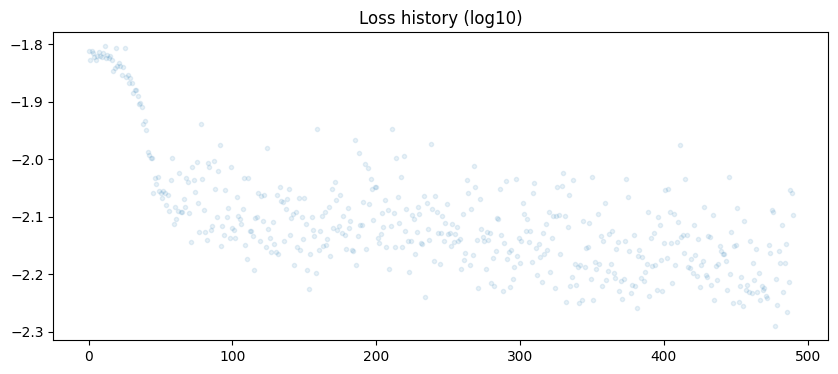

 step: 500, log10(loss): -2.201, log10(best): -2.290, sigma: 2.46e-03

In [ ]:
#@title Training Loop {vertical-output: true}
N_GENERATIONS = 500
BATCH_SIZE = 8
sigma0 = 0.0002
es = cma.CMAEvolutionStrategy(init_vec, sigma0, {'popsize': 64})
POPSIZE = es.popsize
print("popsize:", POPSIZE)

# Precomputed indicator tensor for batched vec(136) -> symmetric 16x16.
# indicator[i,j,k] = 1 iff entry k of the 136-vec maps to position (i,j).
# Off-diagonal entries are mirrored, diagonal entries are written twice with the
# same value, exactly matching vec_to_sym() above.
_iu = np.triu_indices(16)
_indicator = np.zeros((16, 16, 136), dtype=np.float32)
for _k in range(136):
    _r, _c = _iu[0][_k], _iu[1][_k]
    _indicator[_r, _c, _k] = 1.0
    _indicator[_c, _r, _k] = 1.0
indicator_tf = tf.constant(_indicator)

@tf.function(jit_compile=True)
def evaluate_batch(x_init, V, iter_n):
    # x_init: [B, H, W, C]   shared starting state, broadcast to every candidate
    # V:      [P, 136]       all CMA-ES candidate vectors stacked
    # iter_n: scalar int32   number of NCA steps (variable per generation)
    # returns: x_final [P, B, H, W, C], losses_per_candidate [P]
    # P comes from V's static shape, so changing popsize triggers a clean retrace
    # rather than a shape-mismatch crash from a stale Python closure.
    P = V.shape[0]
    B, H, W, C = x_init.shape
    M = tf.einsum('pk,ijk->pij', V, indicator_tf)              # [P, 16, 16]
    x = tf.tile(x_init[None], [P, 1, 1, 1, 1])                  # [P, B, H, W, C]
    for _ in tf.range(iter_n):
        x_flat = tf.reshape(x, [P * B, H, W, C])
        lm = tf.cast(get_living_mask(x_flat), tf.float32)       # [P*B, H, W, 1]
        lm = tf.reshape(lm, [P, B, H, W, 1])
        x = tf.einsum('pbhwc,pcd->pbhwd', x, M)                 # per-candidate mutation
        x = tf.clip_by_value(x, -3., 3.)
        x = x * lm
        x_flat = tf.reshape(x, [P * B, H, W, C])
        x_flat = ca(x_flat)                                     # one fused NCA pass over all candidates
        x = tf.reshape(x_flat, [P, B, H, W, C])
    x_flat = tf.reshape(x, [P * B, H, W, C])
    losses = tf.reshape(loss_f(x_flat), [P, B])
    return x, tf.reduce_mean(losses, axis=1)


for gen in range(N_GENERATIONS):
  iter_n = np.random.randint(64, 96)
  batch = pool.sample(BATCH_SIZE)
  x0 = batch.x
  loss_rank = loss_f(x0).numpy().argsort()[::-1]
  x0 = x0[loss_rank]
  x0[:1] = seed
  x0[1:2] = x0_seed[0]
  if DAMAGE_N:
    damage = 1.0-make_circle_masks(DAMAGE_N, h, w).numpy()[..., None]
    x0[-DAMAGE_N:] *= damage

  candidates = es.ask()                                          # list of POPSIZE arrays of shape (136,)
  V = tf.constant(np.stack(candidates).astype(np.float32))       # [P, 136]
  x_init_t = tf.constant(x0)
  xs_out, fitnesses_t = evaluate_batch(
      x_init_t, V, tf.constant(iter_n, dtype=tf.int32))
  fitnesses = fitnesses_t.numpy().tolist()
  es.tell(candidates, fitnesses)
  elite_idx = int(np.argmin(fitnesses))
  elite_x = xs_out[elite_idx]                                    # tf tensor [B, H, W, C]

  batch.x[:] = elite_x.numpy()
  batch.commit()

  step_i = len(loss_log)
  loss_log.append(min(fitnesses))

  if step_i%10 == 0:
    generate_pool_figures(pool, step_i)
  if step_i%10 == 0:
    clear_output()
    visualize_batch(x0, elite_x, step_i)
    plot_loss(loss_log)
    export_model(ca, 'train_log/%04d'%step_i)

  print(f"\r gen: {len(loss_log)}, log10(loss): {np.log10(min(fitnesses)):.3f}, "
      f"log10(best): {np.log10(min(loss_log)):.3f}, sigma: {es.sigma:.2e}", end='')

loss0 (empty seed):       0.022939
best loss ever:           0.005124
last generation best:     0.006290
last 50 gens mean:        0.006621
sigma:                    2.462e-03
sigma * max axis (D):     3.438e-03    # widest search direction
sigma * min axis (D):     1.374e-03    # narrowest search direction
axis-length ratio D/D:    2.50    # >>1 means covariance is anisotropic
||mean - init_vec||:      2.398e-01


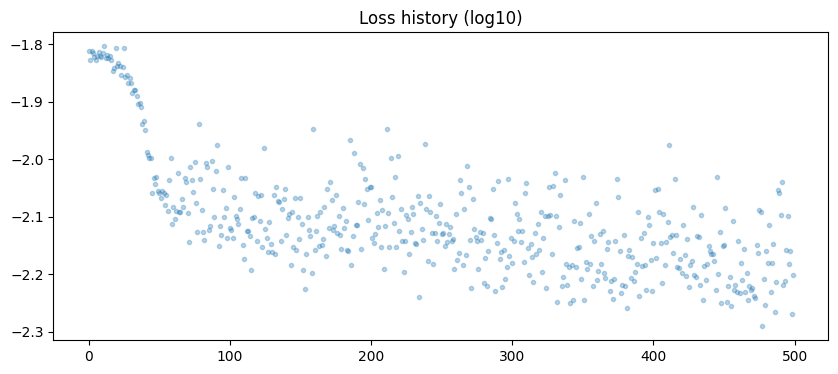

In [20]:
# Diagnostics from CMA-ES state and loss history. No NCA reruns.
print(f"loss0 (empty seed):       {loss0:.6f}")
print(f"best loss ever:           {min(loss_log):.6f}")
print(f"last generation best:     {loss_log[-1]:.6f}")
print(f"last 50 gens mean:        {np.mean(loss_log[-50:]):.6f}")
print(f"sigma:                    {es.sigma:.3e}")
print(f"sigma * max axis (D):     {es.sigma * es.D.max():.3e}    # widest search direction")
print(f"sigma * min axis (D):     {es.sigma * es.D.min():.3e}    # narrowest search direction")
print(f"axis-length ratio D/D:    {es.D.max() / es.D.min():.2f}    # >>1 means covariance is anisotropic")
print(f"||mean - init_vec||:      {np.linalg.norm(np.asarray(es.mean) - init_vec):.3e}")
pl.figure(figsize=(10, 4))
pl.title('Loss history (log10)')
pl.plot(np.log10(loss_log), '.', alpha=0.3)
pl.show()

In [27]:
print(xs_out)

tf.Tensor(
[[[[[ 0.  0.  0. ... -0. -0.  0.]
    [ 0.  0.  0. ... -0. -0.  0.]
    [ 0.  0.  0. ... -0. -0.  0.]
    ...
    [ 0.  0.  0. ...  0.  0.  0.]
    [ 0.  0.  0. ...  0.  0.  0.]
    [ 0.  0.  0. ... -0. -0.  0.]]

   [[ 0.  0.  0. ... -0. -0.  0.]
    [ 0.  0.  0. ...  0.  0.  0.]
    [ 0.  0.  0. ...  0.  0.  0.]
    ...
    [ 0.  0.  0. ...  0.  0.  0.]
    [ 0.  0.  0. ...  0.  0.  0.]
    [ 0.  0.  0. ...  0.  0.  0.]]

   [[ 0.  0.  0. ... -0. -0.  0.]
    [ 0.  0.  0. ...  0.  0.  0.]
    [ 0.  0.  0. ... -0. -0.  0.]
    ...
    [ 0.  0.  0. ...  0.  0.  0.]
    [ 0.  0.  0. ...  0.  0.  0.]
    [ 0.  0.  0. ... -0. -0.  0.]]

   ...

   [[ 0.  0.  0. ...  0.  0.  0.]
    [ 0.  0.  0. ... -0. -0.  0.]
    [ 0.  0.  0. ... -0. -0.  0.]
    ...
    [ 0.  0.  0. ...  0.  0.  0.]
    [ 0.  0.  0. ...  0.  0.  0.]
    [ 0.  0.  0. ...  0.  0.  0.]]

   [[ 0.  0.  0. ...  0.  0.  0.]
    [ 0.  0.  0. ...  0.  0.  0.]
    [ 0.  0.  0. ...  0.  0.  0.]
    ...
    [ 0.  0.  0

In [29]:
# Save the symmetric matrix, in case you want to use combinations of them.
# showing an example.

#TODO
mutation_tensor = elite_x
m_upper = tf.linalg.band_part(mutation_tensor, 0, -1)


tail_sym_t = m_upper + tf.transpose(m_upper) - tf.linalg.tensor_diag(tf.linalg.diag_part(mutation_tensor))
leg_sym_t = m_upper + tf.transpose(m_upper) - tf.linalg.tensor_diag(tf.linalg.diag_part(mutation_tensor))
head_sym_t = m_upper + tf.transpose(m_upper) - tf.linalg.tensor_diag(tf.linalg.diag_part(mutation_tensor))
arm_sym_t = m_upper + tf.transpose(m_upper) - tf.linalg.tensor_diag(tf.linalg.diag_part(mutation_tensor))



red_sym_t = m_upper + tf.transpose(m_upper) - tf.linalg.tensor_diag(tf.linalg.diag_part(mutation_tensor))



blue_sym_t = m_upper + tf.transpose(m_upper) - tf.linalg.tensor_diag(tf.linalg.diag_part(mutation_tensor))


InvalidArgumentError: {{function_node __wrapped__AddV2_device_/job:localhost/replica:0/task:0/device:GPU:0}} required broadcastable shapes [Op:AddV2] name: 

In [22]:
#@title visualize training run
EXP = "default"
import PIL.ImageFont

from matplotlib import font_manager as fm
font_fn = fm.findfont(fm.FontProperties())
font = PIL.ImageFont.truetype(font_fn, 16)

x = seed[None, ...]
if EXP == "default":
  m_upper = tf.linalg.band_part(mutation_tensor, 0, -1)
  mutation_symm_t = m_upper + tf.transpose(m_upper) - tf.linalg.tensor_diag(
      tf.linalg.diag_part(mutation_tensor))
elif EXP == "diag":
  # Experiment: only use the diagonal!
  mutation_symm_t = tf.linalg.tensor_diag(
      tf.linalg.diag_part(mutation_tensor))
elif EXP == "eigvec":
  m_upper = tf.linalg.band_part(mutation_tensor, 0, -1)
  mutation_symm_t = m_upper + tf.transpose(m_upper) - tf.linalg.tensor_diag(
      tf.linalg.diag_part(mutation_tensor))

  eigval, eigvec = np.linalg.eigh(mutation_symm_t)
  eigdelta = eigval - tf.ones([CHANNEL_N])
  eigval = tf.ones([CHANNEL_N]) + eigdelta * 0.5
  mutation_symm_t = eigvec @ tf.linalg.tensor_diag(eigval) @ np.transpose(eigvec)

perturb_step = lambda i: i < 500 or i >= 1000

fn = 'example_run.mp4'
with VideoWriter(fn) as vid:
  for gen in tqdm.trange(2500):
    if gen<200 or gen%5 == 0:
      vis = zoom(to_rgb(x[0]), 4).clip(0, 1)
      #vis = np.concatenate((vis, np.ones((164, vis.shape[1], 3))), axis=0)

      im = np.uint8(vis*255)

      im = PIL.Image.fromarray(im)

      draw = PIL.ImageDraw.Draw(im)

      # compute text:
      steptext = "Step: {}".format(gen)
      perturbtext = "Perturbation: {}".format("ON" if perturb_step(gen) else "OFF")
      perturbcolor = (255,0,0) if perturb_step(gen) else (0, 255, 0)
      # draw.text((x, y),"Sample Text",(r,g,b))
      draw.text((0, 0),steptext,(0,0,0),font=font)
      draw.text((0, 20),perturbtext,perturbcolor,font=font)
      vid.add(np.uint8(im))
      if gen == 500 or gen == 1000:
        # add many frames to effectively pause the video.
        for _ in range(50):
          vid.add(np.uint8(im))
    if perturb_step(gen):
      lm = tf.cast(get_living_mask(x), tf.float32)
      x = x @ mutation_symm_t
      x = tf.clip_by_value(x, -3., 3.)
      x *= lm
    x = ca(x)

mvp.ipython_display(fn, loop=True)

NameError: name 'mutation_tensor' is not defined

In [ ]:
# Create a mosaic of direction mutations!
import PIL.ImageFont

from matplotlib import font_manager as fm
font_fn = fm.findfont(fm.FontProperties())
font = PIL.ImageFont.truetype(font_fn, 16)

# Generate 9 mutation matrices:
all_mutation_symm_t = []
all_distortions = [1.0, 0.5, 0.3, 0.1, 0.0, -0.1, -0.3, -0.5, -1.0]
for d in all_distortions:
  m_upper = tf.linalg.band_part(mutation_tensor, 0, -1)
  mutation_symm_t = m_upper + tf.transpose(m_upper) - tf.linalg.tensor_diag(
      tf.linalg.diag_part(mutation_tensor))

  # d*M + (1-d)*I
  mutation_symm_t = d * mutation_symm_t + (1. - d) * tf.eye(CHANNEL_N)

  all_mutation_symm_t.append(mutation_symm_t)
mutation_symm_t = np.stack(all_mutation_symm_t)
print(mutation_symm_t.shape)

x = np.repeat(seed[None, ...], 9, 0)

fn = 'example_run.mp4'
with VideoWriter(fn) as vid:
  for gen in tqdm.trange(500):
    if gen<200 or gen%5 == 0:
      vis = zoom(tile2d(to_rgb(x), 3), 4).clip(0, 1)
      #vis = np.concatenate((vis, np.ones((164, vis.shape[1], 3))), axis=0)

      im = np.uint8(vis*255)

      im = PIL.Image.fromarray(im)

      draw = PIL.ImageDraw.Draw(im)

      # compute text:
      steptext = "Step: {}".format(gen)
      perturbtext = "Perturbation: {}".format("ON" if perturb_step(gen) else "OFF")
      perturbcolor = (255,0,0) if perturb_step(gen) else (0, 255, 0)
      # draw.text((x, y),"Sample Text",(r,g,b))
      draw.text((0, 0),steptext,(0,0,0),font=font)
      draw.text((0, 20),perturbtext,perturbcolor,font=font)

      # Add mutation direction text.
      for idx, d in enumerate(all_distortions):
        disttext = "direction: {}".format(d)
        if d == 1.0:
          disttext += " (train config)"
        if d == 0.0:
          disttext += " (NOOP)"
        x_unit, y_unit = im.width // 3, im.height // 3
        x_displacement = x_unit // 5
        y_displacement = int(y_unit * 0.9)
        placement = (x_unit * (idx % 3) + x_displacement,
                     y_unit * (idx // 3) + y_displacement)
        draw.text(placement,disttext,(0,0,0),font=font)


      vid.add(np.uint8(im))
      if gen == 500 or gen == 1000:
        # add many frames to effectively pause the video.
        for _ in range(50):
          vid.add(np.uint8(im))
    if perturb_step(gen):
      lm = tf.cast(get_living_mask(x), tf.float32)
      x_t = []
      for d_idx in range(len(all_distortions)):
        x_ti = x[d_idx] @ mutation_symm_t[d_idx]
        x_ti = tf.clip_by_value(x_ti, -3., 3.)
        x_t.append(x_ti)
      x = tf.stack(x_t)
      x *= lm
    x = ca(x)

mvp.ipython_display(fn, loop=True)

In [ ]:
# @title Save data for external demo usage

perturbations_str = json.dumps(np.stack(
    [tail_sym_t, leg_sym_t, head_sym_t,
     arm_sym_t, red_sym_t, blue_sym_t]).tolist())

emoji = '🦎'
model_str = get_model(emoji, output='json')

data_js = '''
  window.GRAPH_URL = URL.createObjectURL(new Blob([`%s`], {type: 'application/json'}));
  window.PERTURBATIONS = %s
'''%(model_str, perturbations_str)

with open("gca_data.js", "w") as f:
  f.write(data_js)


In [ ]:
# @title Download trained perturbations from Github
!wget -O growing_ca_saved_perturbations.zip 'https://github.com/google-research/self-organising-systems/blob/master/adversarial_reprogramming_ca/assets/growing_ca_saved_perturbations.zip?raw=true'
!unzip -oq "growing_ca_saved_perturbations.zip" -d "saved_perturbations"

In [ ]:
# note you can also alternatively just upload the zip file to colab and unzip.
#!unzip -oq "/content/growing_ca_saved_perturbations.zip" -d "saved_perturbations"

In [ ]:
# @title Load saved matrices (for demos and visualizations)

load_dir = "saved_perturbations/"

leg_sym_t = np.load(load_dir + "leg_sym_t.npy")
tail_sym_t = np.load(load_dir + "tail_sym_t.npy")
head_sym_t = np.load(load_dir + "head_sym_t.npy")
arm_sym_t = np.load(load_dir + "arm_sym_t.npy")
red_sym_t = np.load(load_dir + "red_sym_t.npy")
blue_sym_t = np.load(load_dir + "blue_sym_t.npy")

perts_mat_list = [tail_sym_t, leg_sym_t, head_sym_t, arm_sym_t, red_sym_t, blue_sym_t]


In [ ]:
#@title TensorFlow.js Demo {run:"auto", vertical-output: true}
#@markdown Select "CHECKPOINT" model to load the checkpoint created by running cells from the "Training" section of this notebook
import IPython.display

emoji = '🦎'

perturbations_str = json.dumps(np.stack(
    [tail_sym_t, leg_sym_t, head_sym_t,
     arm_sym_t, red_sym_t, blue_sym_t]).tolist())

#@markdown Shift-click to seed the pattern

model_str = get_model(emoji, output='json')

data_js = '''
  window.GRAPH_URL = URL.createObjectURL(new Blob([`%s`], {type: 'application/json'}));
  window.PERTURBATIONS = %s
'''%(model_str, perturbations_str)

display(IPython.display.Javascript(data_js))


IPython.display.HTML('''
<script src="https://cdn.jsdelivr.net/npm/@tensorflow/tfjs@2.3.0/dist/tf.min.js"></script>
<script src="https://cdnjs.cloudflare.com/ajax/libs/cash/4.1.2/cash.min.js"></script>

<canvas id='canvas' style="border: 1px solid black; image-rendering: pixelated;"></canvas>
<div><button type="button" id="reset">Reset</button></div>
<div class="slidecontainer">
    tailPerturbation:
    <input type="range" min="-1.0" max="1.0" value="0.0" class="slider"
      step="0.05" id="tailSlider">
    <span id='tailPerturbation'>0.0</span>
</div>
<div class="slidecontainer">
    legPerturbation:
    <input type="range" min="-1.0" max="1.0" value="0.0" class="slider"
      step="0.05" id="legSlider">
    <span id='legPerturbation'>0.0</span>
</div>
<div class="slidecontainer">
    headPerturbation:
    <input type="range" min="-1.0" max="1.0" value="0.0" class="slider"
      step="0.05" id="headSlider">
    <span id='headPerturbation'>0.0</span>
</div>
<div class="slidecontainer">
    armPerturbation:
    <input type="range" min="-1.0" max="1.0" value="0.0" class="slider"
      step="0.05" id="armSlider">
    <span id='armPerturbation'>0.0</span>
</div>
<div class="slidecontainer">
    redPerturbation:
    <input type="range" min="-1.0" max="1.0" value="0.0" class="slider"
      step="0.05" id="redSlider">
    <span id='redPerturbation'>0.0</span>
</div>
<div class="slidecontainer">
    bluePerturbation:
    <input type="range" min="-1.0" max="1.0" value="0.0" class="slider"
      step="0.05" id="blueSlider">
    <span id='bluePerturbation'>0.0</span>
</div>
<input type="checkbox" id="forcesum1" name="forcesum1">
<label for="forcesum1"> Force sum leq 1</label><br>
<script>
  "use strict";

  const sleep = (ms)=>new Promise(resolve => setTimeout(resolve, ms));

  const parseConsts = model_graph=>{
    const dtypes = {'DT_INT32':['int32', 'intVal', Int32Array],
                    'DT_FLOAT':['float32', 'floatVal', Float32Array]};

    const consts = {};
    model_graph.modelTopology.node.filter(n=>n.op=='Const').forEach((node=>{
      const v = node.attr.value.tensor;
      const [dtype, field, arrayType] = dtypes[v.dtype];
      if (!v.tensorShape.dim) {
        consts[node.name] = [tf.scalar(v[field][0], dtype)];
      } else {
        const shape = v.tensorShape.dim.map(d=>parseInt(d.size));
        let arr;
        if (v.tensorContent) {
          const data = atob(v.tensorContent);
          const buf = new Uint8Array(data.length);
          for (var i=0; i<data.length; ++i) {
            buf[i] = data.charCodeAt(i);
          }
          arr = new arrayType(buf.buffer);
        } else {
          const size = shape.reduce((a, b)=>a*b);
          arr = new arrayType(size);
          arr.fill(v[field][0]);
        }
        consts[node.name] = [tf.tensor(arr, shape, dtype)];
      }
    }));
    return consts;
  }

  let kTail = 0.0;
  let kLeg = 0.0;
  let kHead = 0.0;
  let kArm = 0.0;
  let kRed = 0.0;
  let kBlue = 0.0;

  let forcesum1Ckbx = document.getElementById("forcesum1");
  let tailSlider = document.getElementById("tailSlider");
  let legSlider = document.getElementById("legSlider");
  let headSlider = document.getElementById("headSlider");
  let armSlider = document.getElementById("armSlider");
  let redSlider = document.getElementById("redSlider");
  let blueSlider = document.getElementById("blueSlider");

  $('#tailSlider').on('input', e=>{
      updateK("tail", parseFloat(e.target.value));
  });
  $('#legSlider').on('input', e=>{
      updateK("leg", parseFloat(e.target.value));
  });
  $('#headSlider').on('input', e=>{
      updateK("head", parseFloat(e.target.value));
  });
  $('#armSlider').on('input', e=>{
      updateK("arm", parseFloat(e.target.value));
  });
  $('#redSlider').on('input', e=>{
      updateK("red", parseFloat(e.target.value));
  });
  $('#blueSlider').on('input', e=>{
      updateK("blue", parseFloat(e.target.value));
  });

  const updateKUnchecked = (kid, v) => {
    if (kid == "tail"){
      kTail = v;
      $('#tailPerturbation').text(kTail);
    } else if (kid == "leg"){
      kLeg = v;
      $('#legPerturbation').text(kLeg);
    } else if (kid == "head"){
      kHead = v;
      $('#headPerturbation').text(kHead);
    } else if (kid == "arm"){
      kArm = v;
      $('#armPerturbation').text(kArm);
    } else if (kid == "red"){
      kRed = v;
      $('#redPerturbation').text(kRed);
    } else if (kid == "blue"){
      kBlue = v;
      $('#bluePerturbation').text(kBlue);
    } else {
      console.log("ERROR!");
    }
  }

  const updateK = (kid, v) => {
      if (forcesum1Ckbx.checked == false) {
        updateKUnchecked(kid, v);
      } else {
        // You cannot go over 1.
        let vAbs = Math.abs(v);
        const vSign = Math.sign(v);
        const kTailAbs = Math.abs(kTail);
        const kTailSign = Math.sign(kTail);
        const kLegAbs = Math.abs(kLeg);
        const kLegSign = Math.sign(kLeg);
        const kHeadAbs = Math.abs(kHead);
        const kHeadSign = Math.sign(kHead);
        const kArmAbs = Math.abs(kArm);
        const kArmSign = Math.sign(kArm);
        const kRedAbs = Math.abs(kRed);
        const kRedSign = Math.sign(kRed);
        const kBlueAbs = Math.abs(kBlue);
        const kBlueSign = Math.sign(kBlue);

        let kCurrAbs;
        if (kid == "tail"){
          kCurrAbs = kTailAbs;
        } else if (kid == "leg"){
          kCurrAbs = kLegAbs;
        } else if (kid == "head"){
          kCurrAbs = kHeadAbs;
        } else if (kid == "arm"){
          kCurrAbs = kArmAbs;
        } else if (kid == "red"){
          kCurrAbs = kRedAbs;
        } else if (kid == "blue"){
          kCurrAbs = kBlueAbs;
        }
        let totK = vAbs + kTailAbs + kLegAbs + kHeadAbs + kArmAbs
              + kRedAbs + kBlueAbs - kCurrAbs;
        if (totK <= 1.0) {
          // No problem here, do just like you did before.
          updateKUnchecked(kid, v);
        } else {
          // Prevent v from going over 1.
          if (vAbs > 1.0) {
            vAbs = 1.0;
            totK = vAbs + kTailAbs + kLegAbs + kHeadAbs + kArmAbs
              + kRedAbs + kBlueAbs - kCurrAbs;
          }
          // Subtract the excess from the rest.
          const excess = totK - 1.0;

          const tailContrib = kid == "tail" ? 0.0 : kTailAbs;
          const legContrib = kid == "leg" ? 0.0 : kLegAbs;
          const headContrib = kid == "head" ? 0.0 : kHeadAbs;
          const armContrib = kid == "arm" ? 0.0 : kArmAbs;
          const redContrib = kid == "red" ? 0.0 : kRedAbs;
          const blueContrib = kid == "blue" ? 0.0 : kBlueAbs;
          const totContrib = tailContrib + legContrib + headContrib +
              armContrib + redContrib + blueContrib;

          let tailDecr = 0.0;
          let legDecr = 0.0;
          let headDecr = 0.0;
          let armDecr = 0.0;
          let redDecr = 0.0;
          let blueDecr = 0.0;
          if (totContrib > 1e-6) {
            tailDecr = tailContrib / totContrib * excess;
            legDecr = legContrib / totContrib * excess;
            headDecr = headContrib / totContrib * excess;
            armDecr = armContrib / totContrib * excess;
            redDecr = redContrib / totContrib * excess;
            blueDecr = blueContrib / totContrib * excess;
          }

          kTail = kid == "tail" ? vAbs * vSign : kTailSign * (kTailAbs - tailDecr);
          kLeg = kid == "leg" ? vAbs * vSign : kLegSign * (kLegAbs - legDecr);
          kHead = kid == "head" ? vAbs * vSign : kHeadSign * (kHeadAbs - headDecr);
          kArm = kid == "arm" ? vAbs * vSign : kArmSign * (kArmAbs - armDecr);
          kRed = kid == "red" ? vAbs * vSign : kRedSign * (kRedAbs - redDecr);
          kBlue = kid == "blue" ? vAbs * vSign : kBlueSign * (kBlueAbs - blueDecr);
          $('#tailPerturbation').text(kTail);
          tailSlider.value = kTail;
          $('#legPerturbation').text(kLeg);
          legSlider.value = kLeg;
          $('#headPerturbation').text(kHead);
          headSlider.value = kHead;
          $('#armPerturbation').text(kArm);
          armSlider.value = kArm;
          $('#redPerturbation').text(kRed);
          redSlider.value = kRed;
          $('#bluePerturbation').text(kBlue);
          blueSlider.value = kBlue;
        }
      }
      updatePerturbation();
  }


  let perturbationMatrix = tf.eye(16);

  const perturbations = tf.tensor(PERTURBATIONS);
  const tailPertM = perturbations.gather([0]).squeeze();
  const legPertM = perturbations.gather([1]).squeeze();
  const headPertM = perturbations.gather([2]).squeeze();
  const armPertM = perturbations.gather([3]).squeeze();
  const redPertM = perturbations.gather([4]).squeeze();
  const bluePertM = perturbations.gather([5]).squeeze();

  const I = tf.eye(16);
  const updatePerturbation = () => {
      let kI = 1.0 - kTail - kLeg - kHead - kArm - kRed - kBlue;
      perturbationMatrix = I.mul(kI).
        add(tailPertM.mul(kTail)).
        add(legPertM.mul(kLeg)).
        add(headPertM.mul(kHead)).
        add(armPertM.mul(kArm)).
        add(redPertM.mul(kRed)).
        add(bluePertM.mul(kBlue));
  }

  const run = async ()=>{
    const r = await fetch(GRAPH_URL);
    const consts = parseConsts(await r.json());

    const model = await tf.loadGraphModel(GRAPH_URL);
    Object.assign(model.weights, consts);


    let seed = new Array(16).fill(0).map((x, i)=>i<3?0:1);
    seed = tf.tensor(seed, [1, 1, 1, 16]);

    const D = 96;
    const initState = tf.tidy(()=>{
      const D2 = D/2;
      const a = seed.pad([[0, 0], [D2-1, D2], [D2-1, D2], [0,0]]);
      return a;
    });

    const state = tf.variable(initState);
    const [_, h, w, ch] = state.shape;


    $('#reset').on('click', e=>{
        tf.tidy(()=>{
          state.assign(initState);
        });
    });


    const damage = (x, y, r)=>{
      tf.tidy(()=>{
        const rx = tf.range(0, w).sub(x).div(r).square().expandDims(0);
        const ry = tf.range(0, h).sub(y).div(r).square().expandDims(1);
        const mask = rx.add(ry).greater(1.0).expandDims(2);
        state.assign(state.mul(mask));
      });
    }

    const plantSeed = (x, y)=>{
      const x2 = w-x-seed.shape[2];
      const y2 = h-y-seed.shape[1];
      if (x<0 || x2<0 || y2<0 || y2<0)
        return;
      tf.tidy(()=>{
        const a = seed.pad([[0, 0], [y, y2], [x, x2], [0,0]]);
        state.assign(state.add(a));
      });
    }

    const scale = 4;

    const canvas = document.getElementById('canvas');
    const ctx = canvas.getContext('2d');
    canvas.width = w;
    canvas.height = h;
    canvas.style.width = `${w*scale}px`;
    canvas.style.height = `${h*scale}px`;

    canvas.onmousedown = e=>{
      const x = Math.floor(e.clientX/scale);
        const y = Math.floor(e.clientY/scale);
        if (e.buttons == 1) {
          if (e.shiftKey) {
            plantSeed(x, y);
          } else {
            damage(x, y, 8);
          }
        }
    }
    canvas.onmousemove = e=>{
      const x = Math.floor(e.clientX/scale);
      const y = Math.floor(e.clientY/scale);
      if (e.buttons == 1 && !e.shiftKey) {
        damage(x, y, 8);
      }
    }

    function step() {
      tf.tidy(()=>{
        let new_state = model.execute(
            {x:state, fire_rate:tf.tensor(0.5),
            angle:tf.tensor(0.0), step_size:tf.tensor(1.0)}, ['Identity']);
        new_state = new_state.reshape([-1, 16]);
        new_state = new_state.matMul(perturbationMatrix).reshape([1, D, D, 16]);
        new_state = new_state.clipByValue(-3., +3.);
        state.assign(new_state);
      });
    }

    function render() {
      step();

      const imageData = tf.tidy(()=>{
        const rgba = state.slice([0, 0, 0, 0], [-1, -1, -1, 4]);
        const a = state.slice([0, 0, 0, 3], [-1, -1, -1, 1]);
        const img = tf.tensor(1.0).sub(a).add(rgba).mul(255);
        const rgbaBytes = new Uint8ClampedArray(img.dataSync());
        return new ImageData(rgbaBytes, w, h);
      });
      ctx.putImageData(imageData, 0, 0);

      requestAnimationFrame(render);
    }
    render();
  }
  run();

</script>
''')

## Make videos for article

In [ ]:
#@title visualize runs
import PIL.ImageFont

from matplotlib import font_manager as fm
font_fn = fm.findfont(fm.FontProperties())
font = PIL.ImageFont.truetype(font_fn, 16)


perturb_step = lambda i: i < 500 or i >= 1000

runs_per_perturb = []
for sym_t in perts_mat_list:
  x = seed[None, ...]

  run_frames = []
  run_texts = []
  for gen in tqdm.trange(1500):
    if gen<200 or gen%5 == 0:
      vis = zoom(to_rgb(x[0]), 4).clip(0, 1)
      #vis = np.concatenate((vis, np.ones((164, vis.shape[1], 3))), axis=0)

      im = np.uint8(vis*255)
      run_frames.append(im)

      # Save text for rendering.
      steptext = "Step: {}".format(gen)
      perturbtext = "Perturbation: {}".format("ON" if perturb_step(gen) else "OFF")
      perturbcolor = (255,0,0) if perturb_step(gen) else (0, 255, 0)
      run_texts.append((steptext, perturbtext,perturbcolor))
      if gen == 500 or gen == 1000:
        # add many frames to effectively pause the video.
        for _ in range(50):
          run_frames.append(im)
          run_texts.append((steptext, perturbtext,perturbcolor))
    if perturb_step(gen):
      lm = tf.cast(get_living_mask(x), tf.float32)
      x = x @ sym_t
      x = tf.clip_by_value(x, -3., 3.)
      x *= lm
    x = ca(x)

  runs_per_perturb.append(run_frames)

# generate text for each frame with a skeleton like the one above:


num_frames = len(runs_per_perturb[0])

fn = 'mosaic_run.mp4'
with VideoWriter(fn) as vid:
  for gen in tqdm.trange(num_frames):
    frame_images = [run_frames[gen] for run_frames in runs_per_perturb]
    im = tile2d(frame_images)

    im = PIL.Image.fromarray(im)
    draw = PIL.ImageDraw.Draw(im)

    # compute text:
    steptext, perturbtext, perturbcolor = run_texts[gen]
    # draw.text((x, y),"Sample Text",(r,g,b))
    draw.text((0, 0),steptext,(0,0,0),font=font)
    draw.text((0, 20),perturbtext,perturbcolor,font=font)
    vid.add(np.uint8(im))

mvp.ipython_display(fn, loop=True)

In [ ]:
#@title interpolating directions
import PIL.ImageFont

from matplotlib import font_manager as fm
font_fn = fm.findfont(fm.FontProperties())
font = PIL.ImageFont.truetype(font_fn, 16)

perturb_step = lambda i: True

# Generate 5 mutation matrices:
pert_1 = tail_sym_t
pert_2 = leg_sym_t
all_mutation_symm_t = []
all_distortions = [1.0, 0.75, 0.5, 0.25, 0.0]
for d in all_distortions:

  mutation_symm_t = d * pert_1 + (1. - d) * pert_2


  all_mutation_symm_t.append(mutation_symm_t)
mutation_symm_t = np.stack(all_mutation_symm_t)
print(mutation_symm_t.shape)

x = np.repeat(seed[None, ...], 5, 0)

fn = 'example_run.mp4'
with VideoWriter(fn) as vid:
  for gen in tqdm.trange(1500):
    if gen<200 or gen%5 == 0:
      vis = zoom(tile2d(to_rgb(x), 5), 4).clip(0, 1)
      #vis = np.concatenate((vis, np.ones((164, vis.shape[1], 3))), axis=0)

      im = np.uint8(vis*255)

      im = PIL.Image.fromarray(im)

      draw = PIL.ImageDraw.Draw(im)

      # compute text:
      steptext = "Step: {}".format(gen)
      perturbtext = "Perturbation: {}".format("ON" if perturb_step(gen) else "OFF")
      perturbcolor = (255,0,0) if perturb_step(gen) else (0, 255, 0)
      # draw.text((x, y),"Sample Text",(r,g,b))
      draw.text((0, 0),steptext,(0,0,0),font=font)
      draw.text((0, 20),perturbtext,perturbcolor,font=font)

      # Add mutation direction text.
      for idx, d in enumerate(all_distortions):
        disttext = "tail k: {} | leg k: {}".format(d, 1.0 - d)
        x_unit, y_unit = im.width // 5, im.height // 1
        x_displacement = x_unit // 5
        y_displacement = int(y_unit * 0.9)
        placement = (x_unit * (idx % 5) + x_displacement,
                     y_unit * (idx // 5) + y_displacement)
        draw.text(placement,disttext,(0,0,0),font=font)


      vid.add(np.uint8(im))
    if perturb_step(gen):
      lm = tf.cast(get_living_mask(x), tf.float32)
      # Uncertain if there is a faster way:
      x_t = []
      for d_idx in range(len(all_distortions)):
        x_ti = x[d_idx] @ mutation_symm_t[d_idx]
        x_ti = tf.clip_by_value(x_ti, -3., 3.)
        x_t.append(x_ti)
      x = tf.stack(x_t)
      x *= lm
    x = ca(x)

mvp.ipython_display(fn, loop=True)

In [ ]:
# @title combinations of mutations
import PIL.ImageFont

from matplotlib import font_manager as fm
font_fn = fm.findfont(fm.FontProperties())
font = PIL.ImageFont.truetype(font_fn, 16)

x = seed[None, ...]

mutation_symm_t = tail_sym_t + leg_sym_t - tf.eye(16)

perturb_step = lambda i: i < 500 or i >= 1000

fn = 'example_run.mp4'
with VideoWriter(fn) as vid:
  for gen in tqdm.trange(1500):
    if gen<200 or gen%5 == 0:
      vis = zoom(to_rgb(x[0]), 4).clip(0, 1)
      #vis = np.concatenate((vis, np.ones((164, vis.shape[1], 3))), axis=0)

      im = np.uint8(vis*255)

      im = PIL.Image.fromarray(im)

      draw = PIL.ImageDraw.Draw(im)

      # compute text:
      steptext = "Step: {}".format(gen)
      perturbtext = "Perturbation: {}".format("ON" if perturb_step(gen) else "OFF")
      perturbcolor = (255,0,0) if perturb_step(gen) else (0, 255, 0)
      # draw.text((x, y),"Sample Text",(r,g,b))
      draw.text((0, 0),steptext,(0,0,0),font=font)
      draw.text((0, 20),perturbtext,perturbcolor,font=font)
      vid.add(np.uint8(im))
      if gen == 500 or gen == 1000:
        # add many frames to effectively pause the video.
        for _ in range(50):
          vid.add(np.uint8(im))
    if perturb_step(gen):
      lm = tf.cast(get_living_mask(x), tf.float32)
      x = x @ mutation_symm_t
      x = tf.clip_by_value(x, -3., 3.)
      x *= lm
    x = ca(x)

mvp.ipython_display(fn, loop=True)

In [ ]:
# @title Create a mosaic of direction mutations!
import PIL.ImageFont

from matplotlib import font_manager as fm
font_fn = fm.findfont(fm.FontProperties())
font = PIL.ImageFont.truetype(font_fn, 16)

# Generate 9 mutation matrices:
all_mutation_symm_t = []
all_distortions = [1.0, 0.5, 0.3, 0.1, 0.0, -0.1, -0.3, -0.5, -1.0]
for d in all_distortions:

  # Luca's faster way: d*M + (1-d)*I
  mutation_symm_t = d * tail_sym_t + (1. - d) * tf.eye(CHANNEL_N)

  """
  eigval, eigvec = np.linalg.eigh(mutation_symm_t)
  eigdelta = eigval - tf.ones([CHANNEL_N])
  eigval = tf.ones([CHANNEL_N]) + eigdelta * d
  mutation_symm_t = eigvec @ tf.linalg.tensor_diag(eigval) @ np.transpose(eigvec)
  """

  all_mutation_symm_t.append(mutation_symm_t)
mutation_symm_t = np.stack(all_mutation_symm_t)
print(mutation_symm_t.shape)

x = np.repeat(seed[None, ...], 9, 0)

fn = 'example_run.mp4'
with VideoWriter(fn) as vid:
  for gen in tqdm.trange(500):
    if gen<200 or gen%5 == 0:
      vis = zoom(tile2d(to_rgb(x), 3), 4).clip(0, 1)
      #vis = np.concatenate((vis, np.ones((164, vis.shape[1], 3))), axis=0)

      im = np.uint8(vis*255)

      im = PIL.Image.fromarray(im)

      draw = PIL.ImageDraw.Draw(im)

      # compute text:
      steptext = "Step: {}".format(gen)
      perturbtext = "Perturbation: {}".format("ON" if perturb_step(gen) else "OFF")
      perturbcolor = (255,0,0) if perturb_step(gen) else (0, 255, 0)
      # draw.text((x, y),"Sample Text",(r,g,b))
      draw.text((0, 0),steptext,(0,0,0),font=font)
      draw.text((0, 20),perturbtext,perturbcolor,font=font)

      # Add mutation direction text.
      for idx, d in enumerate(all_distortions):
        disttext = "direction: {}".format(d)
        if d == 1.0:
          disttext += " (train config)"
        if d == 0.0:
          disttext += " (NOOP)"
        x_unit, y_unit = im.width // 3, im.height // 3
        x_displacement = x_unit // 5
        y_displacement = int(y_unit * 0.9)
        placement = (x_unit * (idx % 3) + x_displacement,
                     y_unit * (idx // 3) + y_displacement)
        draw.text(placement,disttext,(0,0,0),font=font)


      vid.add(np.uint8(im))
      if gen == 500 or gen == 1000:
        # add many frames to effectively pause the video.
        for _ in range(50):
          vid.add(np.uint8(im))
    if perturb_step(gen):
      lm = tf.cast(get_living_mask(x), tf.float32)
      # Uncertain if there is a faster way:
      x_t = []
      for d_idx in range(len(all_distortions)):
        x_ti = x[d_idx] @ mutation_symm_t[d_idx]
        x_ti = tf.clip_by_value(x_ti, -3., 3.)
        x_t.append(x_ti)
      x = tf.stack(x_t)
      x *= lm
    x = ca(x)

mvp.ipython_display(fn, loop=True)